In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import CategoricalNB

In [102]:
df= pd.read_csv('golf_dataset.csv')
df.sample()

,Outlook,Temperature,Humidity,Windy,Play Golf
101,Sunny,Cool,Normal,True,No


In [103]:
# le= LabelEncoder()
# le.fit_transform(df)

# scikit-learn’s LabelEncoder expects a 1D array (single column), but you're giving it a 2D DataFrame.

In [104]:
le= LabelEncoder()
df2= df.copy()
for col in df.columns:
    df2[col]=le.fit_transform(df2[col])
df2.sample(3)

,Outlook,Temperature,Humidity,Windy,Play Golf
80,2,0,0,0,0
178,1,1,0,1,0
137,2,1,0,1,0


In [105]:
X= df2.iloc[:, 0:4]
y= df2.iloc[:, -1] 

# Train Test Split

In [106]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection

In [107]:
model= CategoricalNB(alpha= 1.0)

# CategoricalNB is best for categorical features
# alpha=1.0 → Laplace smoothing (avoids zero-probability)

model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [108]:
y_pred= model.predict(X_test)
print("Test Results:", y_test.values)
print("Predicted Results:", y_pred)

Test Results: [0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0
 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0]
Predicted Results: [0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 1 1 0 0 0 1 1 0 1 0
 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 1 0 0]


# Evaluation

In [109]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Cross Validation:", np.mean(cross_val_score(model, X, y, cv= 5, scoring='accuracy')))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9672131147540983
Cross Validation: 0.9504918032786887
Confusion Matrix:
 [[30  1]
 [ 1 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        31
           1       0.97      0.97      0.97        30

    accuracy                           0.97        61
   macro avg       0.97      0.97      0.97        61
weighted avg       0.97      0.97      0.97        61



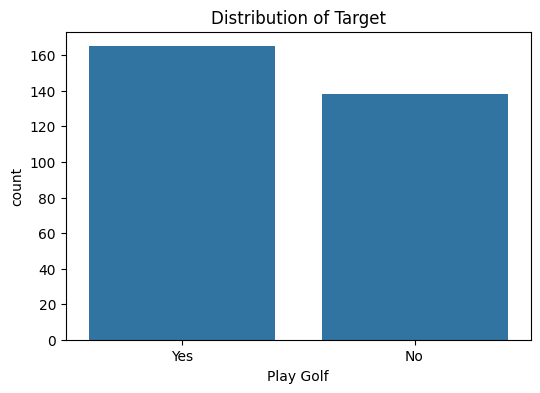

In [110]:
plt.figure(figsize=(6,4))
sns.countplot(data= df, x= 'Play Golf')
plt.title("Distribution of Target")
plt.show()

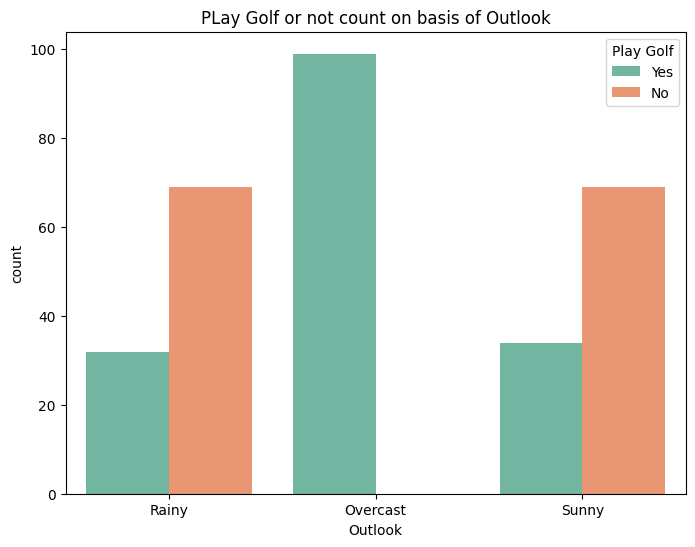

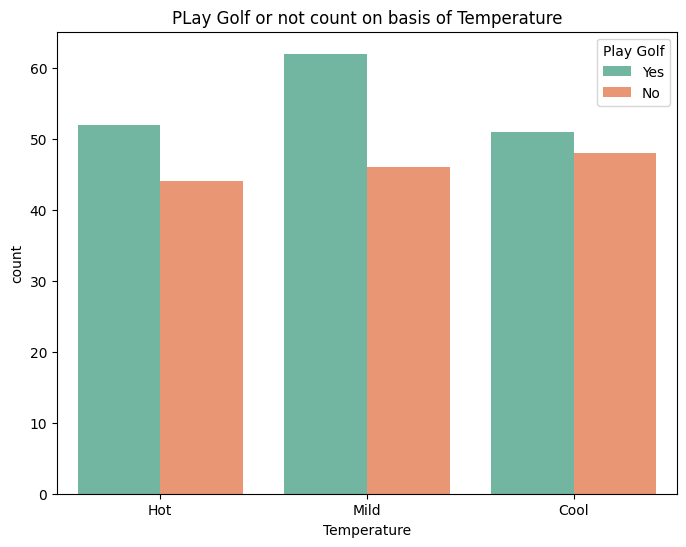

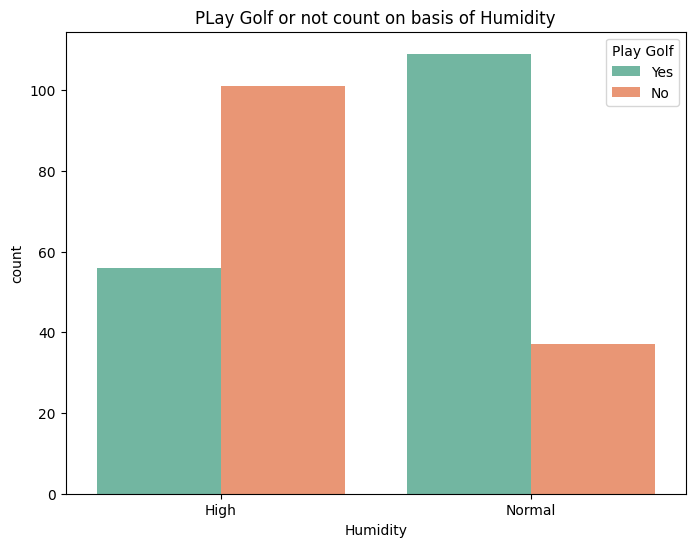

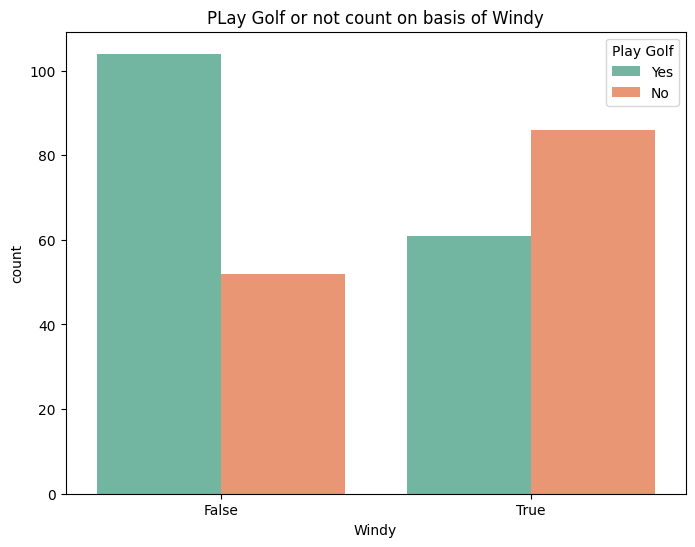

In [111]:
for col in X.columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data= df, x= df[col], hue= 'Play Golf' , palette='Set2')
    plt.title(f"PLay Golf or not count on basis of {col}")
    plt.show()